# 美崙之星 Hedonic Pricing Model 估價報告

本 notebook 以美崙之星實價登錄資料建立 log-linear hedonic pricing model，目的在於估計標的物總價，並檢查模型的共線性、殘差分布、異質變異與高影響力樣本。

In [9]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys

PROJECT_DIR = Path.cwd()
if not (PROJECT_DIR / "utils.py").exists():
    PROJECT_DIR = Path(r"D:\Github\Personal-Project\ndhu\房地產")
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

from utils import (
    add_centered_square,
    NUMERIC_COLUMNS,
    describe_columns,
    ols,
    plot_residual_diagnostics,
    predict_price,
    prepare_model_rows,
    print_residual_diagnostics,
    print_summary,
    print_vif_table,
    read_xlsx_records,
    variance_inflation_factors,
)

DATA_PATH = PROJECT_DIR / "591_實價登錄整理.xlsx"
print(DATA_PATH.exists(), DATA_PATH)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
True d:\Github\Personal-Project\ndhu\房地產\591_實價登錄整理.xlsx


## 1. 資料來源與研究目的

資料來源為整理後的實價登錄 Excel，樣本鎖定同一社區或高度可比較的交易。應變數採 `ln(成交總價_含車位_萬元)`，主要自變數包含建坪、樓層、屋齡、屋齡平方、是否有車位與中高樓層虛擬變數。

使用 log-linear 模型的原因是係數可以近似解讀為百分比影響，也能降低總價尺度差異對模型的影響。

In [10]:
records = read_xlsx_records(DATA_PATH)
print(f"Loaded {len(records)} rows")
print("Columns:", list(records[0]))
for row in records[:3]:
    print(row)

Loaded 46 rows
Columns: ['Case_ID', '成交年月', '成交日期', '成交總價_含車位_萬元', '建坪_含車位', '樓層', '總樓層', '屋齡', '屋齡平方', '有車位虛擬變數', '中高樓層虛擬變數', '地址', '到東華附小距離(google)', '到球崙公園距離(google)', '到門諾距離(google)']
{'Case_ID': '7256601', '成交年月': '115-02', '成交日期': '2026-02-01', '成交總價_含車位_萬元': '1880', '建坪_含車位': '67.400000000000006', '樓層': '5', '總樓層': '9', '屋齡': '9.31', '屋齡平方': '86.676100000000005', '有車位虛擬變數': '1', '中高樓層虛擬變數': '1', '地址': '中美路111號 | 5樓之1', '到東華附小距離(google)': '700', '到球崙公園距離(google)': '1300', '到門諾距離(google)': '750'}
{'Case_ID': '7121628', '成交年月': '114-10', '成交日期': '2025-10-13', '成交總價_含車位_萬元': '670', '建坪_含車位': '25.5', '樓層': '1', '總樓層': '9', '屋齡': '9', '屋齡平方': '81', '有車位虛擬變數': '1', '中高樓層虛擬變數': '0', '地址': '中美路111號之6 | 1,2樓', '到東華附小距離(google)': '700', '到球崙公園距離(google)': '1300', '到門諾距離(google)': '750'}
{'Case_ID': '7091875', '成交年月': '114-06', '成交日期': '2025-06-08', '成交總價_含車位_萬元': '1870', '建坪_含車位': '65.400000000000006', '樓層': '4', '總樓層': '9', '屋齡': '8.66', '屋齡平方': '74.995599999999996', '有車位虛擬變數': '1', '中高樓層

## 2. 變數清理與模型設定

同一棟建物的 `總樓層` 與三個距離欄位沒有變異，無法在回歸中估計效果。`成交年分數` 與 `屋齡` 在單一建物樣本中高度重疊，因此主模型保留屋齡與屋齡平方；另外提供一個「時間趨勢、無屋齡」的敏感度模型作交叉檢查。

In [11]:
model_rows = prepare_model_rows(records)

for item in describe_columns(model_rows, NUMERIC_COLUMNS + ["成交年分數"]):
    print(
        f"{item['欄位']}: "
        f"min={item['min']:,.4g}, "
        f"max={item['max']:,.4g}, "
        f"unique={item['unique']}"
    )

成交總價_含車位_萬元: min=670, max=2,838, unique=33
建坪_含車位: min=25.5, max=102.2, unique=21
樓層: min=1, max=9, unique=8
總樓層: min=9, max=9, unique=1
屋齡: min=0.15, max=9.31, unique=23
屋齡平方: min=0.0225, max=86.68, unique=23
有車位虛擬變數: min=0, max=1, unique=2
中高樓層虛擬變數: min=0, max=1, unique=2
到東華附小距離(google): min=700, max=700, unique=1
到球崙公園距離(google): min=1,300, max=1,300, unique=1
到門諾距離(google): min=750, max=750, unique=1
成交年分數: min=2,017, max=2,026, unique=23


## 3. 主模型：log-linear hedonic model

主模型：`ln(總價) = 建坪 + 樓層 + 屋齡 + 屋齡平方 + 車位 + 中高樓層`。

此模型保留屋齡平方，用來捕捉屋齡對價格的非線性影響。不過原始屋齡與屋齡平方通常會高度相關，因此後續會用 VIF 檢查共線性。

In [12]:
main_features = [
    "建坪_含車位",
    "樓層",
    "屋齡",
    "屋齡平方",
    "有車位虛擬變數",
    "中高樓層虛擬變數",
]

main_result = ols(model_rows, "ln_price", main_features)
print_summary(main_result)

n = 46, R^2 = 0.9095, Adjusted R^2 = 0.8956, RMSE(log) = 0.0708
----------------------------------------------------------------------------------------------------------------
變數                                  係數           標準誤          t值          p值         約略%影響
----------------------------------------------------------------------------------------------------------------
截距                            6.146262      0.095550      64.325      0.0000              
建坪_含車位                        0.017587      0.001000      17.582      0.0000         1.77%
樓層                            0.027021      0.007923       3.410      0.0006         2.74%
屋齡                            0.022517      0.016801       1.340      0.1802         2.28%
屋齡平方                         -0.000950      0.001995      -0.476      0.6340        -0.09%
有車位虛擬變數                      -0.052475      0.036648      -1.432      0.1522        -5.11%
中高樓層虛擬變數                     -0.093696      0.044529      -2.104      0.0

### 3.1 主模型共線性與殘差診斷

VIF 判讀上，通常 VIF 大於 5 代表需要注意，大於 10 代表共線性偏嚴重。殘差診斷則觀察 Jarque-Bera 常態性檢定、Breusch-Pagan 異質變異檢定，以及 Cook's distance 高影響力樣本。

主模型 VIF
變數                               R^2         VIF              判讀
----------------------------------------------------------------
建坪_含車位                        0.2831       1.395             可接受
樓層                            0.6998       3.331             可接受
屋齡                            0.9411      16.965              嚴重
屋齡平方                          0.9415      17.080              嚴重
有車位虛擬變數                       0.1557       1.184             可接受
中高樓層虛擬變數                      0.6936       3.264             可接受

主模型殘差診斷
Residual summary
count       : 46
mean        : -0.0000
std         : 0.0716
min         : -0.1877
q1          : -0.0339
median      : -0.0033
q3          : 0.0320
max         : 0.2239
skew        : 0.4898
kurtosis    : 4.8023
Jarque-Bera: stat=8.0654, p-value=0.0177
Breusch-Pagan: LM=21.4044, df=6, p-value=0.0016

Top 5 Cook's distance
Case_ID | 成交日期 | 成交總價_含車位_萬元 | 建坪_含車位 | 樓層 | 屋齡 | residual | student_resid | leverage | cooks_d
----------------------------

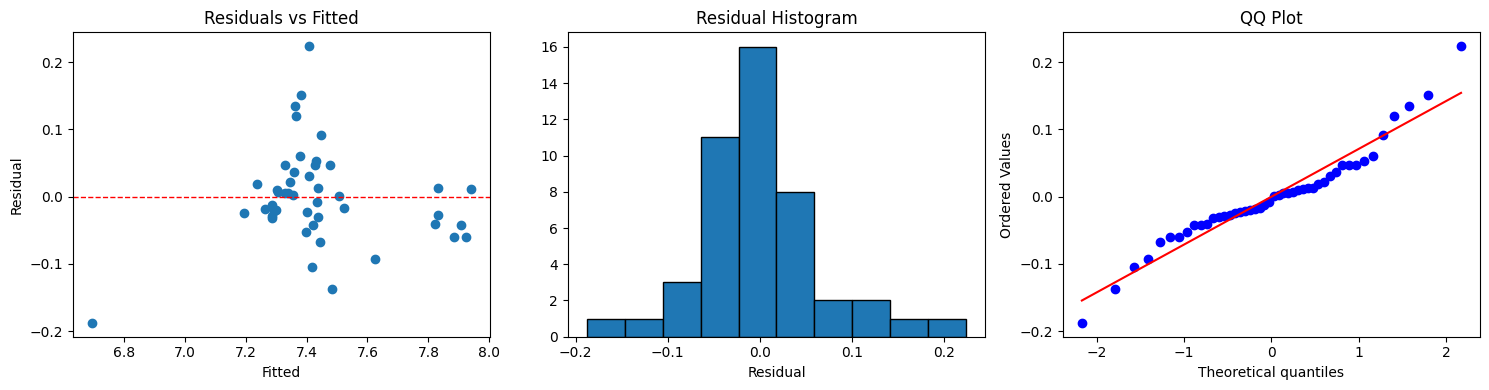

In [13]:
print("主模型 VIF")
print_vif_table(variance_inflation_factors(model_rows, main_features))

print("\n主模型殘差診斷")
print_residual_diagnostics(
    model_rows,
    main_result,
    main_features,
    id_cols=["Case_ID", "成交日期", "成交總價_含車位_萬元", "建坪_含車位", "樓層", "屋齡"],
)

plot_residual_diagnostics(main_result);

## 4. 共線性修正：屋齡中心化模型

若 `屋齡` 與 `屋齡平方` 的 VIF 過高，較合理的處理方式不是直接刪除平方項，而是先將屋齡中心化：

`屋齡_center = 屋齡 - 平均屋齡`

再建立 `屋齡_center平方`。這樣仍保留非線性效果，同時降低原變數與平方項之間的機械性共線性。

In [14]:
centered_rows, age_mean = add_centered_square(
    model_rows,
    "屋齡",
    centered_col="屋齡_center",
    squared_col="屋齡_center平方",
)

centered_features = [
    "建坪_含車位",
    "樓層",
    "屋齡_center",
    "屋齡_center平方",
    "有車位虛擬變數",
    "中高樓層虛擬變數",
]

centered_result = ols(centered_rows, "ln_price", centered_features)
print(f"平均屋齡 = {age_mean:.2f} 年")
print_summary(centered_result)

print("\n屋齡中心化模型 VIF")
print_vif_table(variance_inflation_factors(centered_rows, centered_features))

平均屋齡 = 1.92 年
n = 46, R^2 = 0.9095, Adjusted R^2 = 0.8956, RMSE(log) = 0.0708
----------------------------------------------------------------------------------------------------------------
變數                                  係數           標準誤          t值          p值         約略%影響
----------------------------------------------------------------------------------------------------------------
截距                            6.186039      0.090529      68.332      0.0000              
建坪_含車位                        0.017587      0.001000      17.582      0.0000         1.77%
樓層                            0.027021      0.007923       3.410      0.0006         2.74%
屋齡_center                     0.018866      0.009611       1.963      0.0496         1.90%
屋齡_center平方                  -0.000950      0.001995      -0.476      0.6340        -0.09%
有車位虛擬變數                      -0.052475      0.036648      -1.432      0.1522        -5.11%
中高樓層虛擬變數                     -0.093696      0.044529      -

## 5. 敏感度模型：時間趨勢、無屋齡

因為同一建物的屋齡會隨成交時間一起增加，這個版本改放 `成交年分數`，不放屋齡，用來觀察時間趨勢下的估價差異。


In [15]:
time_features = [
    "成交年分數",
    "建坪_含車位",
    "樓層",
    "有車位虛擬變數",
    "中高樓層虛擬變數",
]

time_result = ols(model_rows, "ln_price", time_features)
print_summary(time_result)


n = 46, R^2 = 0.9089, Adjusted R^2 = 0.8976, RMSE(log) = 0.0710
----------------------------------------------------------------------------------------------------------------
變數                                  係數           標準誤          t值          p值         約略%影響
----------------------------------------------------------------------------------------------------------------
截距                          -23.675816      8.809478      -2.688      0.0072              
成交年分數                         0.014792      0.004350       3.401      0.0007         1.49%
建坪_含車位                        0.017570      0.000990      17.746      0.0000         1.77%
樓層                            0.027658      0.007734       3.576      0.0003         2.80%
有車位虛擬變數                      -0.058073      0.034388      -1.689      0.0913        -5.64%
中高樓層虛擬變數                     -0.097423      0.043402      -2.245      0.0248        -9.28%


### 5.1 時間趨勢模型共線性與殘差診斷

時間趨勢模型 VIF
變數                               R^2         VIF              判讀
----------------------------------------------------------------
成交年分數                         0.1375       1.159             可接受
建坪_含車位                        0.2822       1.393             可接受
樓層                            0.6909       3.236             可接受
有車位虛擬變數                       0.0594       1.063             可接受
中高樓層虛擬變數                      0.6837       3.161             可接受

時間趨勢模型殘差診斷
Residual summary
count       : 46
mean        : -0.0000
std         : 0.0718
min         : -0.1993
q1          : -0.0324
median      : -0.0018
q3          : 0.0298
max         : 0.2287
skew        : 0.4195
kurtosis    : 5.0476
Jarque-Bera: stat=9.3855, p-value=0.0092
Breusch-Pagan: LM=21.4331, df=5, p-value=0.0007

Top 5 Cook's distance
Case_ID | 成交日期 | 成交總價_含車位_萬元 | 建坪_含車位 | 樓層 | 屋齡 | residual | student_resid | leverage | cooks_d
---------------------------------------------------------------------------------------

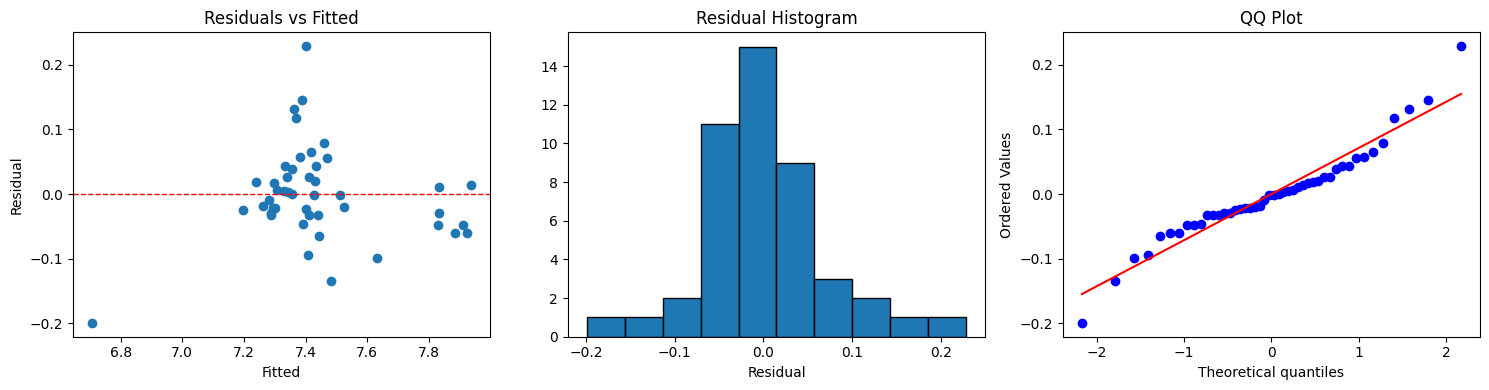

In [16]:
print("時間趨勢模型 VIF")
print_vif_table(variance_inflation_factors(model_rows, time_features))

print("\n時間趨勢模型殘差診斷")
print_residual_diagnostics(
    model_rows,
    time_result,
    time_features,
    id_cols=["Case_ID", "成交日期", "成交總價_含車位_萬元", "建坪_含車位", "樓層", "屋齡"],
)

plot_residual_diagnostics(time_result);

## 6. 標的物估價與模型比較

PDF 標的物為中美路 111 號、約 67.44 坪、中高樓層華廈。下方示範先假設 5 樓、9.3 年屋齡、有車位；實際樓層、屋齡、車位可以改 `target`。

主模型、屋齡中心化模型與時間趨勢模型會一起列出，作為估價敏感度比較。

In [17]:
target = {
    "成交年分數": 2026 + (5 - 1) / 12,
    "建坪_含車位": 67.44,
    "樓層": 5,
    "屋齡": 9.3,
    "屋齡平方": 9.3 ** 2,
    "有車位虛擬變數": 1,
    "中高樓層虛擬變數": 1,
}
target["屋齡_center"] = target["屋齡"] - age_mean
target["屋齡_center平方"] = target["屋齡_center"] ** 2

for label, result, features in [
    ("主模型", main_result, main_features),
    ("屋齡中心化模型", centered_result, centered_features),
    ("時間趨勢敏感度模型", time_result, time_features),
]:
    ln_pred, price_pred = predict_price(result, features, target)
    print(f"{label}: ln(總價)={ln_pred:.4f}, 總價={price_pred:,.0f} 萬元, 單價={price_pred / target['建坪_含車位']:,.2f} 萬元/坪")


主模型: ln(總價)=7.4485, 總價=1,717 萬元, 單價=25.46 萬元/坪
屋齡中心化模型: ln(總價)=7.4485, 總價=1,717 萬元, 單價=25.46 萬元/坪
時間趨勢敏感度模型: ln(總價)=7.4648, 總價=1,746 萬元, 單價=25.88 萬元/坪


## 7. 報告結論與限制

- 這份資料有 46 筆實價登錄，樣本數偏小，因此估計結果應視為輔助估價工具，而非唯一價格依據。
- 主模型的距離變數與總樓層因為沒有變異，無法估計其邊際效果。
- 原始主模型若出現 `屋齡` 與 `屋齡平方` VIF 過高，代表兩者存在結構性共線性；報告中應優先採用屋齡中心化模型作為較穩定版本。
- 若 Breusch-Pagan 檢定顯著，表示可能存在異質變異；係數方向仍可參考，但顯著性判讀應保守。
- Cook's distance 較高的交易應回頭檢查是否為特殊戶別、特殊樓層、特殊坪數或交易條件，不宜未說明就直接刪除。
- 同一棟建物中，成交時間與屋齡高度重疊，不建議同時放在同一個模型裡硬解釋。
- 最終估價建議搭配 5 個可比較案例的 Sales Comparison Adjustments 表交叉檢查。